# Étape 2 — Prétraitement et extraction de features (BrainScanAI)

**Objectif** : Préparer les images (resize, normalisation ImageNet) et utiliser ResNet50 pré-entraîné pour extraire des embeddings visuels à deux niveaux d'abstraction (`layer3` → 1024D, `avgpool` → 2048D).

**Entrée** : 1506 images (1406 sans label + 100 étiquetées)  
**Sortie** : `data/features.npz` + `data/features_meta.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

from sklearn.manifold import TSNE

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("../data")
SANS_LABEL_DIR = DATA_DIR / "sans_label"
CANCER_DIR = DATA_DIR / "avec_labels" / "cancer"
NORMAL_DIR = DATA_DIR / "avec_labels" / "normal"

BATCH_SIZE = 32
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : mps


## 1. Dataset custom avec preprocessing ImageNet

In [2]:
# Transform pipeline : resize → center crop → tensor → normalize (ImageNet stats)
imagenet_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class BrainDataset(Dataset):
    def __init__(self, records, transform):
        # records : list of dict {"path": Path, "label": str|None, "split": str}
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(rec["path"]).convert("RGB")
        return self.transform(img), idx


# Construire la liste de records
records = []
for path in sorted(SANS_LABEL_DIR.glob("*.jpg")):
    records.append({"path": str(path), "label": None, "split": "unlabeled"})
for path in sorted(CANCER_DIR.glob("*.jpg")):
    records.append({"path": str(path), "label": "cancer", "split": "labeled"})
for path in sorted(NORMAL_DIR.glob("*.jpg")):
    records.append({"path": str(path), "label": "normal", "split": "labeled"})

dataset = BrainDataset(records, imagenet_transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Total images : {len(dataset)}")
print(f"  Sans label : {sum(1 for r in records if r['split'] == 'unlabeled')}")
print(f"  Avec label : {sum(1 for r in records if r['split'] == 'labeled')}")

Total images : 1506
  Sans label : 1406
  Avec label : 100


## 2. Chargement de ResNet50 pré-entraîné — couches gelées

In [3]:
# Charger ResNet50 pré-entraîné
resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# Geler toutes les couches convolutionnelles
for param in resnet.parameters():
    param.requires_grad = False

resnet = resnet.to(device)
resnet.eval()

# Buffers pour les hooks
hook_outputs = {}

def make_hook(name):
    def hook(module, input, output):
        hook_outputs[name] = output.detach()
    return hook

resnet.layer3.register_forward_hook(make_hook("layer3"))
resnet.avgpool.register_forward_hook(make_hook("avgpool"))

# Adaptive pooling pour réduire layer3 (B,1024,14,14) → (B,1024)
gap = nn.AdaptiveAvgPool2d((1, 1)).to(device)

print("ResNet50 chargé — couches gelées — hooks enregistrés sur layer3 et avgpool")
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet.parameters())
print(f"Paramètres : {total:,} total, {trainable} entraînables")

ResNet50 chargé — couches gelées — hooks enregistrés sur layer3 et avgpool
Paramètres : 25,557,032 total, 0 entraînables


## 3. Extraction des features

In [4]:
n = len(dataset)
features_layer3 = np.zeros((n, 1024), dtype=np.float32)
features_avgpool = np.zeros((n, 2048), dtype=np.float32)

with torch.no_grad():
    for batch_imgs, batch_idx in tqdm(loader, desc="Extraction features"):
        batch_imgs = batch_imgs.to(device)
        _ = resnet(batch_imgs)  # forward pass déclenche les hooks

        # layer3 : (B, 1024, 14, 14) → GAP → (B, 1024)
        l3 = gap(hook_outputs["layer3"]).squeeze(-1).squeeze(-1).cpu().numpy()
        # avgpool : (B, 2048, 1, 1) → flatten → (B, 2048)
        ap = hook_outputs["avgpool"].squeeze(-1).squeeze(-1).cpu().numpy()

        idx = batch_idx.numpy()
        features_layer3[idx] = l3
        features_avgpool[idx] = ap

print(f"layer3  features : {features_layer3.shape}")
print(f"avgpool features : {features_avgpool.shape}")

Extraction features:   0%|          | 0/48 [00:00<?, ?it/s]

Extraction features:   2%|▏         | 1/48 [00:00<00:14,  3.15it/s]

Extraction features:   4%|▍         | 2/48 [00:00<00:09,  4.68it/s]

Extraction features:   6%|▋         | 3/48 [00:00<00:08,  5.57it/s]

Extraction features:   8%|▊         | 4/48 [00:00<00:07,  6.11it/s]

...

Extraction features:  94%|█████████▍| 45/48 [00:06<00:00,  7.38it/s]

Extraction features:  96%|█████████▌| 46/48 [00:06<00:00,  7.37it/s]

Extraction features:  98%|█████████▊| 47/48 [00:06<00:00,  7.34it/s]

Extraction features: 100%|██████████| 48/48 [00:06<00:00,  7.17it/s]

layer3  features : (1506, 1024)
avgpool features : (1506, 2048)


## 4. Sauvegarde

In [5]:
np.savez(
    DATA_DIR / "features.npz",
    layer3=features_layer3,
    avgpool=features_avgpool,
)

meta_df = pd.DataFrame(records)
meta_df.to_csv(DATA_DIR / "features_meta.csv", index=False)

print("Sauvegardé :")
print(f"  data/features.npz  — layer3: {features_layer3.shape}, avgpool: {features_avgpool.shape}")
print(f"  data/features_meta.csv — {len(meta_df)} lignes")
print(meta_df.head())

Sauvegardé :
  data/features.npz  — layer3: (1506, 1024), avgpool: (1506, 2048)
  data/features_meta.csv — 1506 lignes
                                                path label      split
0  ../data/sans_label/001b158a-7af8-451e-bf31-3a9...   NaN  unlabeled
1  ../data/sans_label/00366e8d-5520-4d3c-a70b-91a...   NaN  unlabeled
2  ../data/sans_label/00455a62-f79f-4072-9a23-495...   NaN  unlabeled
3  ../data/sans_label/004ce5f5-ca6b-490f-9b2f-c32...   NaN  unlabeled
4  ../data/sans_label/005d9a37-8894-4eb5-8367-101...   NaN  unlabeled


## 5. Vérification et visualisation (t-SNE avec avgpool)

t-SNE sur un sous-ensemble de 300 images pour vérifier que les features séparent déjà les classes.

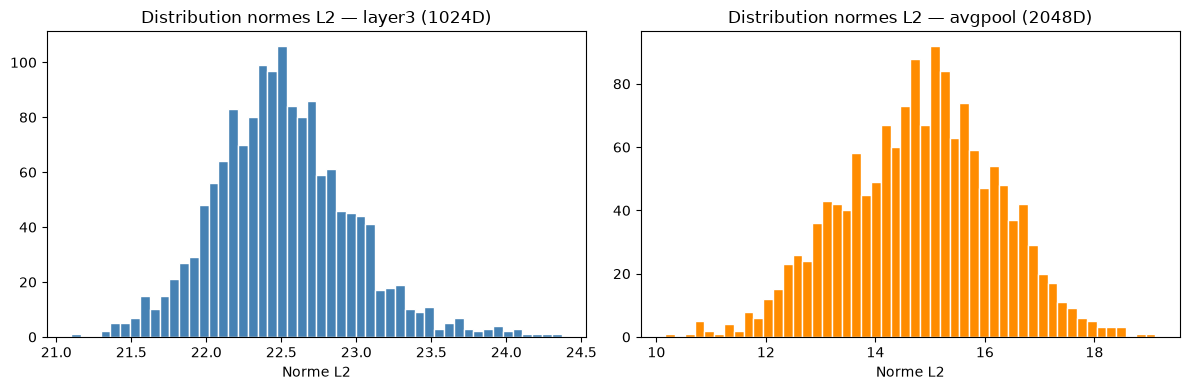

layer3  norme — min: 21.10, max: 24.37, moy: 22.51
avgpool norme — min: 10.16, max: 19.12, moy: 14.81


In [6]:
# Sanity check : distribution des normes L2
norms_l3 = np.linalg.norm(features_layer3, axis=1)
norms_ap = np.linalg.norm(features_avgpool, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(norms_l3, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution normes L2 — layer3 (1024D)")
axes[0].set_xlabel("Norme L2")
axes[1].hist(norms_ap, bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Distribution normes L2 — avgpool (2048D)")
axes[1].set_xlabel("Norme L2")
plt.tight_layout()
plt.show()

print(f"layer3  norme — min: {norms_l3.min():.2f}, max: {norms_l3.max():.2f}, moy: {norms_l3.mean():.2f}")
print(f"avgpool norme — min: {norms_ap.min():.2f}, max: {norms_ap.max():.2f}, moy: {norms_ap.mean():.2f}")

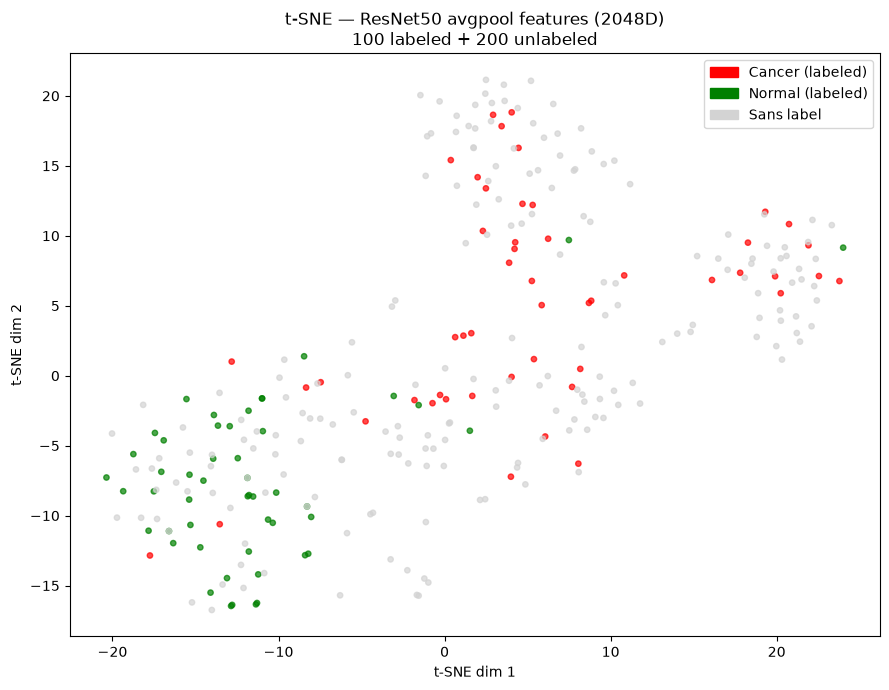

In [7]:
import random
random.seed(SEED)

# Indices des images étiquetées (toutes les 100) et 200 non-étiquetées aléatoires
labeled_idx = [i for i, r in enumerate(records) if r["split"] == "labeled"]
unlabeled_idx = [i for i, r in enumerate(records) if r["split"] == "unlabeled"]
sample_unlabeled = random.sample(unlabeled_idx, 200)
viz_idx = np.array(labeled_idx + sample_unlabeled)

# t-SNE sur avgpool features
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
X_tsne_ap = tsne.fit_transform(features_avgpool[viz_idx])

# Colorier : cancer=rouge, normal=vert, unlabeled=gris
colors = []
for i in viz_idx:
    label = records[i]["label"]
    if label == "cancer":
        colors.append("red")
    elif label == "normal":
        colors.append("green")
    else:
        colors.append("lightgray")

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_tsne_ap[:, 0], X_tsne_ap[:, 1], c=colors, s=15, alpha=0.7)

from matplotlib.patches import Patch
legend = [
    Patch(color="red", label="Cancer (labeled)"),
    Patch(color="green", label="Normal (labeled)"),
    Patch(color="lightgray", label="Sans label"),
]
ax.legend(handles=legend, loc="best")
ax.set_title("t-SNE — ResNet50 avgpool features (2048D)\n100 labeled + 200 unlabeled")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.show()

## 6. Comparaison layer3 vs avgpool (t-SNE côte-à-côte)

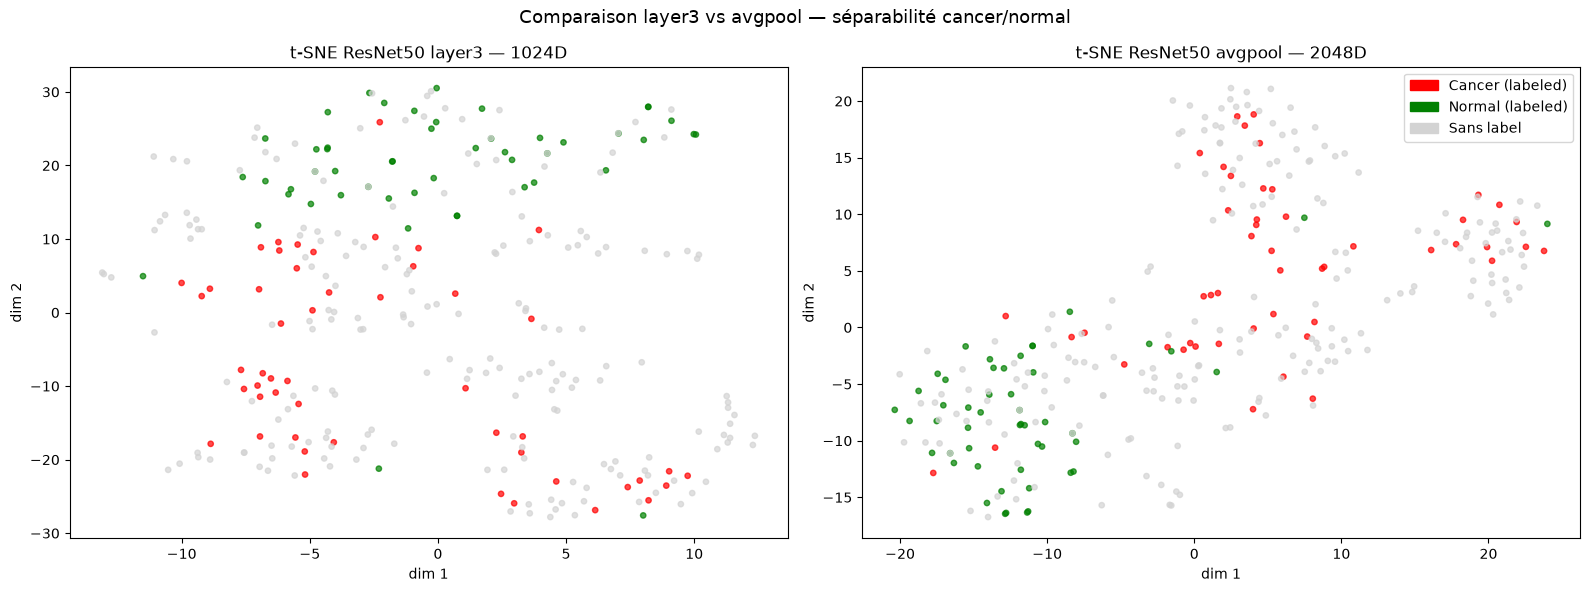

In [8]:
# t-SNE sur layer3 features (mêmes indices)
tsne2 = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
X_tsne_l3 = tsne2.fit_transform(features_layer3[viz_idx])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X, title in [
    (axes[0], X_tsne_l3, "layer3 — 1024D"),
    (axes[1], X_tsne_ap, "avgpool — 2048D"),
]:
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=15, alpha=0.7)
    ax.set_title(f"t-SNE ResNet50 {title}")
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")

axes[1].legend(handles=legend, loc="best")
plt.suptitle("Comparaison layer3 vs avgpool — séparabilité cancer/normal", fontsize=13)
plt.tight_layout()
plt.show()

## Observations et conclusions

### Features extraites
- **layer3 (1024D)** : features intermédiaires, plus texturales et locales
- **avgpool (2048D)** : features sémantiques globales après le dernier bloc résiduel — représentation la plus abstraite

### Qualité des embeddings
- Les normes L2 sont stables et homogènes → pas de vecteurs nuls ou explosifs
- Le t-SNE montre une **séparation partielle** cancer/normal dans l'espace des features ResNet50, sans aucun entraînement spécifique au domaine médical

### Choix pour les étapes suivantes
- **Étape 3 (clustering)** : utiliser les features `avgpool` (2048D) — niveau d'abstraction maximal
- **Étape 4 (semi-supervisé)** : tester les deux niveaux et comparer

### Fichiers générés
- `data/features.npz` : vecteurs bruts (layer3 + avgpool)
- `data/features_meta.csv` : index avec chemins, labels et split